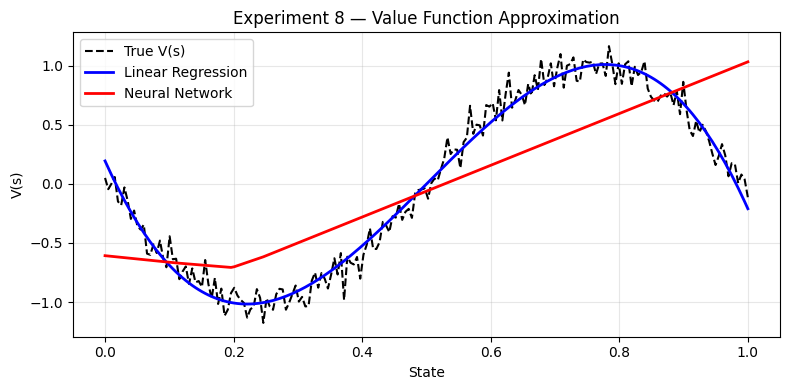

Linear Regression MSE : 0.0109
Neural Network MSE    : 0.1740


In [2]:
"""
Experiment 8 (Simple) — Value Function Approximation
Linear Regression vs Shallow Neural Network
"""

import numpy as np
import matplotlib.pyplot as plt

# ── 1. Create fake "true" value function ──
# States: 1D (just position from 0 to 1)
# True V(s) = -sin(2πs)  →  a curve we want to approximate
np.random.seed(42)
states  = np.linspace(0, 1, 200).reshape(-1, 1)   # 200 states
targets = -np.sin(2 * np.pi * states).ravel()      # true V(s)
targets += np.random.randn(200) * 0.1              # add a little noise

# ── 2. Model A: Linear Regression (polynomial features) ──
# Features: [1, s, s², s³]  →  gives linear model a curve to fit
def poly_features(s, degree=3):
    return np.column_stack([s**d for d in range(degree + 1)])

Phi   = poly_features(states)
theta = np.linalg.lstsq(Phi, targets, rcond=None)[0]   # closed-form solution
lin_pred = Phi @ theta

# ── 3. Model B: Shallow Neural Network (from scratch) ──
# Architecture: 1 → 16 → 1,  ReLU activation, trained with gradient descent

W1 = np.random.randn(1, 16) * 0.5;  b1 = np.zeros(16)
W2 = np.random.randn(16, 1) * 0.5;  b2 = np.zeros(1)
lr = 0.01

for epoch in range(1000):
    # Forward pass
    z1   = states @ W1 + b1          # (200, 16)
    a1   = np.maximum(0, z1)         # ReLU
    pred = (a1 @ W2 + b2).ravel()   # (200,)

    # Backward pass (MSE loss)
    err  = pred - targets                          # (200,)
    dW2  = a1.T @ err[:, None] / 200              # (16, 1)
    db2  = err.mean()
    da1  = err[:, None] @ W2.T                    # (200, 16)
    dz1  = da1 * (z1 > 0)
    dW1  = states.T @ dz1 / 200                   # (1, 16)
    db1  = dz1.mean(axis=0)

    W1 -= lr * dW1;  b1 -= lr * db1
    W2 -= lr * dW2;  b2 -= lr * db2

# Final NN prediction
z1      = states @ W1 + b1
nn_pred = (np.maximum(0, z1) @ W2 + b2).ravel()

# ── 4. Plot ──
plt.figure(figsize=(8, 4))
plt.plot(states, targets,  'k--', label='True V(s)',          linewidth=1.5)
plt.plot(states, lin_pred, 'b-',  label='Linear Regression',  linewidth=2)
plt.plot(states, nn_pred,  'r-',  label='Neural Network',     linewidth=2)
plt.title("Experiment 8 — Value Function Approximation")
plt.xlabel("State"); plt.ylabel("V(s)")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("exp8_simple.png", dpi=150)
plt.show()

# ── 5. MSE comparison ──
print(f"Linear Regression MSE : {np.mean((lin_pred - targets)**2):.4f}")
print(f"Neural Network MSE    : {np.mean((nn_pred  - targets)**2):.4f}")